<a href="https://colab.research.google.com/github/tojotk/ict_assesment/blob/main/casestudy_computer_vision.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
pip install tensorflow

In [1]:

from tensorflow.keras.datasets import cifar100

## Load dataset

In [3]:
# Load dataset
(X_train, y_train), (X_test, y_test) = cifar100.load_data()

169001437/169001437 ━━━━━━━━━━━━━━━━━━━━ 3725s 22us/step


## Check the Dataset

In [4]:
print("Training Images :", X_train.shape)
print("Training Labels :", y_train.shape)

print("Testing Images :", X_test.shape)
print("Testing Labels :", y_test.shape)

Training Images : (50000, 32, 32, 3)
Training Labels : (50000, 1)
Testing Images : (10000, 32, 32, 3)
Testing Labels : (10000, 1)


## Libraries

In [5]:
import tensorflow as tf
import matplotlib.pyplot as plt
import numpy as np
from tensorflow.keras.datasets import cifar100
from tensorflow.keras.applications import VGG16
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Flatten, Dense

## Display a Sample Image

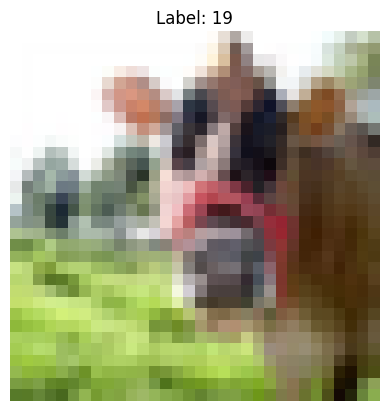

In [6]:
plt.imshow(X_train[0])
plt.title(f"Label: {y_train[0][0]}")
plt.axis("off")
plt.show()

## Normalize the Images

In [7]:
X_train = X_train.astype("float32") / 255.0
X_test = X_test.astype("float32") / 255.0

## Build the CNN Model

In [8]:
model = tf.keras.Sequential([

    tf.keras.layers.Conv2D(32, (3,3), activation='relu',
                           padding='same',
                           input_shape=(32,32,3)),
    tf.keras.layers.MaxPooling2D(2,2),

    tf.keras.layers.Conv2D(64, (3,3), activation='relu',
                           padding='same'),
    tf.keras.layers.MaxPooling2D(2,2),

    tf.keras.layers.Conv2D(128, (3,3), activation='relu',
                           padding='same'),
    tf.keras.layers.MaxPooling2D(2,2),

    tf.keras.layers.Flatten(),

    tf.keras.layers.Dense(256, activation='relu'),

    tf.keras.layers.Dropout(0.5),

    tf.keras.layers.Dense(100, activation='softmax')
])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


## View the Model

In [9]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 32, 32, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 16, 16, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 8, 8, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 4, 4, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 2048)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │       524,544 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 100)            │        25,700 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 643,492 (2.45 MB)

 Trainable params: 643,492 (2.45 MB)

 Non-trainable params: 0 (0.00 B)

## Compile the Model

In [10]:
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

## Train the Model

In [18]:
history = model.fit(
    X_train,
    y_train,
    epochs=10,
    batch_size=64,
    validation_split=0.2
)

Epoch 1/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 4s 6ms/step - accuracy: 0.4250 - loss: 2.1362 - val_accuracy: 0.3977 - val_loss: 2.3622
Epoch 2/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.4406 - loss: 2.0678 - val_accuracy: 0.3883 - val_loss: 2.4115
Epoch 3/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 4s 6ms/step - accuracy: 0.4526 - loss: 1.9794 - val_accuracy: 0.4000 - val_loss: 2.3438
Epoch 4/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 5s 5ms/step - accuracy: 0.4708 - loss: 1.9077 - val_accuracy: 0.4022 - val_loss: 2.3908
Epoch 5/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.4865 - loss: 1.8338 - val_accuracy: 0.4002 - val_loss: 2.3874
Epoch 6/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 4s 6ms/step - accuracy: 0.4995 - loss: 1.7773 - val_accuracy: 0.4023 - val_loss: 2.3855
Epoch 7/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 5s 5ms/step - accuracy: 0.5163 - loss: 1.6970 - val_accuracy: 0.3996 - val_loss: 2.4402
Epoch 8/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.5293 - loss: 1.6453 - val_accuracy: 0.

## Evaluate

In [20]:
loss, accuracy = model.evaluate(X_test, y_test)

print("Test Accuracy:", accuracy)

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.4105 - loss: 2.4890
Test Accuracy: 0.4104999899864197


## Plot Accuracy

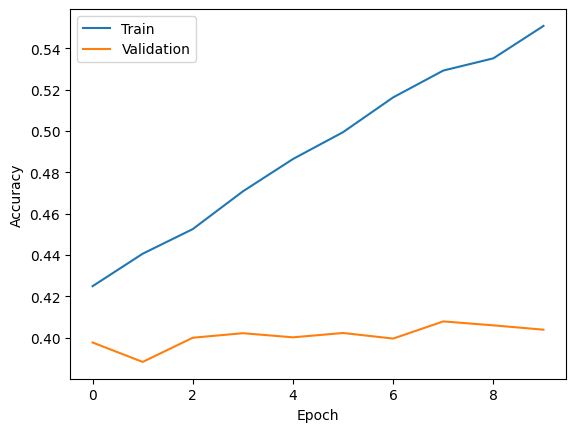

In [21]:
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])

plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend(["Train", "Validation"])
plt.show()

## Plot Loss

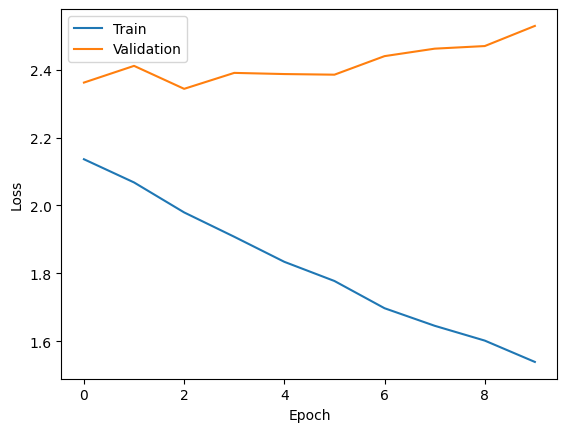

In [22]:
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend(["Train", "Validation"])
plt.show()

## Load VGG16

In [24]:
base_model = VGG16(
    weights='imagenet',
    include_top=False,
    input_shape=(224, 224, 3)
)

base_model.trainable = False

58889256/58889256 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


## Build Model

Model: "sequential_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ vgg16 (Functional)              │ (None, 7, 7, 512)      │    14,714,688 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_6 (Flatten)             │ (None, 25088)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 512)            │    12,845,568 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 100)            │        51,300 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 27,611,556 (105.33 MB)

 Trainable params: 12,896,868 (49.20 MB)

 Non-trainable params: 14,714,688 (56.13 MB)

Epoch 1/5
782/782 ━━━━━━━━━━━━━━━━━━━━ 334s 421ms/step - accuracy: 0.0164 - loss: 4.5224 - val_accuracy: 0.0374 - val_loss: 4.3514
Epoch 2/5
782/782 ━━━━━━━━━━━━━━━━━━━━ 327s 417ms/step - accuracy: 0.0209 - loss: 4.4155 - val_accuracy: 0.0404 - val_loss: 4.2826
Epoch 3/5
782/782 ━━━━━━━━━━━━━━━━━━━━ 322s 411ms/step - accuracy: 0.0241 - loss: 4.3815 - val_accuracy: 0.0473 - val_loss: 4.2583
Epoch 4/5
782/782 ━━━━━━━━━━━━━━━━━━━━ 331s 422ms/step - accuracy: 0.0260 - loss: 4.3397 - val_accuracy: 0.0581 - val_loss: 4.1291
Epoch 5/5
782/782 ━━━━━━━━━━━━━━━━━━━━ 335s 428ms/step - accuracy: 0.0300 - loss: 4.3121 - val_accuracy: 0.0623 - val_loss: 4.0780
157/157 ━━━━━━━━━━━━━━━━━━━━ 54s 343ms/step - accuracy: 0.0623 - loss: 4.0780
VGG16 Test Loss: 4.077955722808838
VGG16 Test Accuracy: 0.062300000339746475


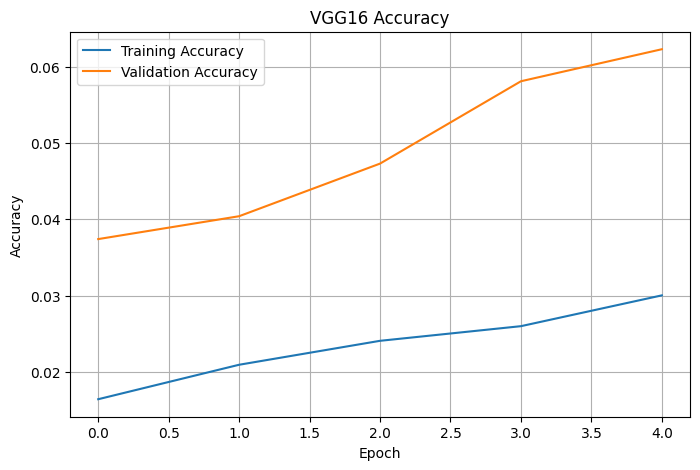

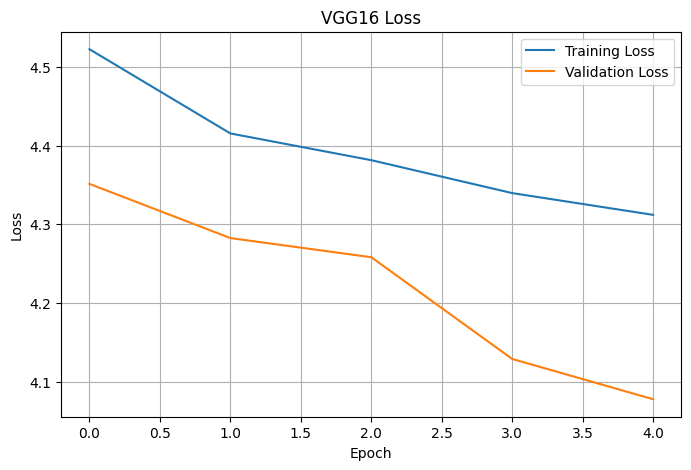

In [41]:
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint
from tensorflow.keras.layers import Dropout # Import Dropout layer

# Building the VGG Model

vgg_model = Sequential([
    base_model,
    Flatten(),

    Dense(512, activation='relu'),
    Dropout(0.5),

    Dense(100, activation='softmax')
])

vgg_model.summary()

# compile the model
vgg_model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

# adding callbacks
vgg_checkpoint = ModelCheckpoint(
    "best_vgg16.keras",
    monitor="val_accuracy",
    save_best_only=True
)

early_stop = EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True
)

def preprocess_image(image, label):
    image = tf.image.resize(image, (224, 224)) # Resize images to 224x224
    return image, label

# Create tf.data.Dataset for training
# Apply preprocessing (resizing) in batches during training
train_dataset = tf.data.Dataset.from_tensor_slices((X_train, y_train))
train_dataset = train_dataset.map(preprocess_image, num_parallel_calls=tf.data.AUTOTUNE)
train_dataset = train_dataset.shuffle(buffer_size=1000).batch(64).prefetch(tf.data.AUTOTUNE)

# Create tf.data.Dataset for testing
test_dataset = tf.data.Dataset.from_tensor_slices((X_test, y_test))
test_dataset = test_dataset.map(preprocess_image, num_parallel_calls=tf.data.AUTOTUNE)
test_dataset = test_dataset.batch(64).prefetch(tf.data.AUTOTUNE)

# training the model
history_vgg = vgg_model.fit(
    train_dataset,
    epochs=5,
    callbacks=[early_stop, vgg_checkpoint],
    validation_data=test_dataset
)

# evaluate the model
vgg_loss, vgg_accuracy = vgg_model.evaluate(test_dataset)

print("VGG16 Test Loss:", vgg_loss)
print("VGG16 Test Accuracy:", vgg_accuracy)

## Plots

# Plot Accuracy
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
plt.plot(history_vgg.history['accuracy'], label='Training Accuracy')
plt.plot(history_vgg.history['val_accuracy'], label='Validation Accuracy')

plt.title("VGG16 Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.grid(True)
plt.show()

# Loss Accuracy
plt.figure(figsize=(8,5))
plt.plot(history_vgg.history['loss'], label='Training Loss')
plt.plot(history_vgg.history['val_loss'], label='Validation Loss')

plt.title("VGG16 Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.grid(True)
plt.show()

## Comparing both models

In [44]:
import pandas as pd

comparison = pd.DataFrame({
    "Model": ["Custom CNN", "VGG16"],
    "Test Accuracy": [accuracy, vgg_accuracy],
    "Test Loss": [loss, vgg_loss]
})

display(comparison)

,Model,Test Accuracy,Test Loss
0,Custom CNN,0.4105,2.489026
1,VGG16,0.0623,4.077956


## Architecture Diagram

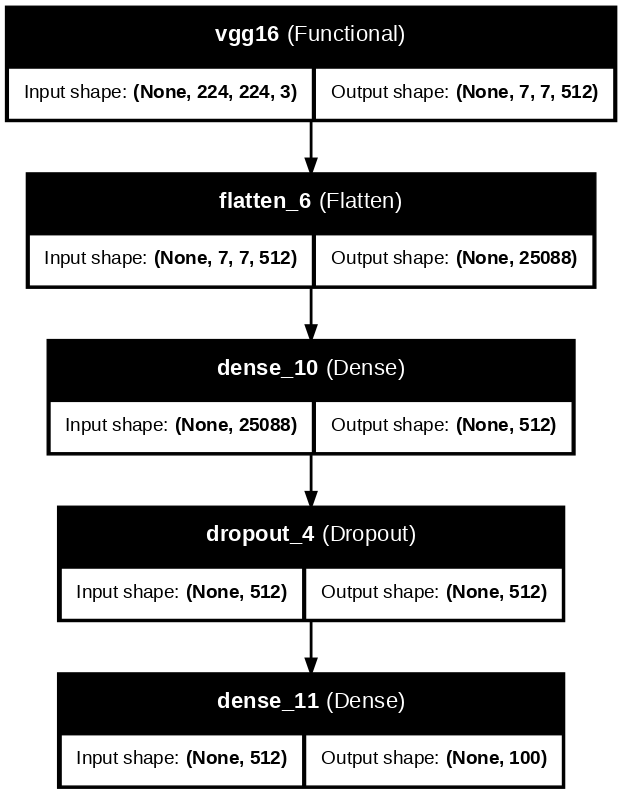

In [46]:
from tensorflow.keras.utils import plot_model
from IPython.display import Image

# Architecture Diagram

## Custom CNN

plot_model(
    model,
    to_file='custom_cnn_architecture.png',
    show_shapes=True,
    show_layer_names=True,
    dpi=100
)

# Displaying the diagram
Image('custom_cnn_architecture.png')

## VGG Model

plot_model(
    vgg_model,
    to_file='vgg16_architecture.png',
    show_shapes=True,
    show_layer_names=True,
    dpi=100
)

# Displaying the diagram
Image('vgg16_architecture.png')